# PROJECT SPRINT 9

Lo has hecho de maravilla en el curso de TripleTen y te han ofrecido hacer prácticas en el departamento de analítica de Showz, una empresa de venta de entradas de eventos. Tu primera tarea es ayudar a optimizar los gastos de marketing. 

Cuentas con:
* Registros del servidor con datos sobre las visitas a Showz desde enero de 2017 hasta diciembre de 2018;
* Un archivo con los pedidos en este periodo;
* Estadísticas de gastos de marketing.

Lo que vas a investigar: 
* Cómo los clientes usan el servicio;
* Cuándo empiezan a comprar;
* Cuánto dinero aporta cada cliente a la compañía;
* Cuándo los ingresos cubren el costo de adquisición de los clientes.

## Paso 1. Acceda los datos y prepáralos para el análisis


Almacena los datos de visitas, pedidos y gastos en variables.  Optimiza los datos para el análisis. Asegúrate de que cada columna contenga el tipo de datos correcto. 

In [98]:
# Importar las librerías

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import math
import numpy as np

In [99]:
# Crear dataframe

df_costs = pd.read_csv(r'C:\Users\Carlo\Documents\TripleTen\Jupyter\PROYECTOS_SPRINTS\Datasets_S9\costs_us.csv')
df_orders = pd.read_csv(r'C:\Users\Carlo\Documents\TripleTen\Jupyter\PROYECTOS_SPRINTS\Datasets_S9\orders_log_us.csv') 
df_visits = pd.read_csv(r'C:\Users\Carlo\Documents\TripleTen\Jupyter\PROYECTOS_SPRINTS\Datasets_S9\visits_log_us.csv')

Revisamos los datos con los que vamos a trabajar

In [100]:
# Costos

df_costs.info()

df_costs.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


,source_id,dt,costs
2451,10,2018-02-28,10.92
2210,10,2017-07-02,2.50
1576,5,2017-10-03,249.43
2061,9,2018-02-01,27.78
700,2,2018-05-06,51.37


In [101]:
# Buscar duplicados y valores únicos para dataframe 'costs'

print('Hay:', df_costs.duplicated().sum(),' valores duplicados en el dataframe costs')
print('Hay:', df_costs['dt'].nunique(),' valores únicos en las fechas')
print('Valores nulos en el dataframe costs:',df_costs.isna().sum()) 

print(df_costs['dt'].unique())


Hay: 0  valores duplicados en el dataframe costs
Hay: 364  valores únicos en las fechas
Valores nulos en el dataframe costs: source_id    0
dt           0
costs        0
dtype: int64
['2017-06-01' '2017-06-02' '2017-06-03' '2017-06-04' '2017-06-05'
 '2017-06-06' '2017-06-07' '2017-06-08' '2017-06-09' '2017-06-10'
 '2017-06-11' '2017-06-12' '2017-06-13' '2017-06-14' '2017-06-15'
 '2017-06-16' '2017-06-17' '2017-06-18' '2017-06-19' '2017-06-20'
 '2017-06-21' '2017-06-22' '2017-06-23' '2017-06-24' '2017-06-25'
 '2017-06-26' '2017-06-27' '2017-06-28' '2017-06-29' '2017-06-30'
 '2017-07-01' '2017-07-02' '2017-07-03' '2017-07-04' '2017-07-05'
 '2017-07-06' '2017-07-07' '2017-07-08' '2017-07-09' '2017-07-10'
 '2017-07-11' '2017-07-12' '2017-07-13' '2017-07-14' '2017-07-15'
 '2017-07-16' '2017-07-17' '2017-07-18' '2017-07-19' '2017-07-20'
 '2017-07-21' '2017-07-22' '2017-07-23' '2017-07-24' '2017-07-25'
 '2017-07-26' '2017-07-27' '2017-07-28' '2017-07-29' '2017-07-30'
 '2017-07-31' '2017-08-01

El dataframe 'costs' tiene 2,542 valores, de los cuáles 364 son únicos en las fechas. A pesar de que la plataforma menciona que el periodo de análisis abarca desde Enero 2017 hasta Diciembre 2018, los valores únicos van de Junio 2017 a Mayo 2018; lo que hace sentido ya que muestra 364 valores únicos, uno para cada día del año. No hay valores duplicados ni nulos para el dataframe 'costs. 

Se opta por cambiar el tipo de dato de la columna 'dt' a *datetime*. Asimismo, por elección de formato, se cambian los nombres de las columnas

In [102]:
# Cambiar nombres de las columnas

df_costs = df_costs.rename(columns={
    'source_id': 'source_id', 
    'dt': 'date',
    'costs': 'source_cost'
})

df_costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   source_id    2542 non-null   int64  
 1   date         2542 non-null   object 
 2   source_cost  2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [103]:
# Convertir columna 'dt' a tipo de dato datetime

df_costs['date'] = pd.to_datetime(df_costs['date'])
df_costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   source_id    2542 non-null   int64         
 1   date         2542 non-null   datetime64[ns]
 2   source_cost  2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


Revisamos el dataframe "Orders"

In [104]:
# Orders

df_orders.info()

df_orders.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


,Buy Ts,Revenue,Uid
16609,2017-11-08 11:37:00,3.05,3861290379055670058
47546,2018-05-16 22:32:00,14.67,8201607855698185400
33343,2018-02-07 10:23:00,7.33,1448744338531511945
13861,2017-10-21 11:30:00,3.05,1853921653418225900
1295,2017-06-12 16:49:00,1.22,765389942000447725


In [105]:
# Buscar duplicados y valores únicos para dataframe 'orders'

print('Hay:', df_orders.duplicated().sum(),' valores duplicados en el dataframe orders')
print('Hay:', df_orders['Uid'].nunique(),' valores únicos en el ID de usuario')
print('Valores duplicados de identificador de usuario', df_orders['Uid'].duplicated().sum())
print('Valores nulos en el dataframe orders:')
print(df_orders.isna().sum())

Hay: 0  valores duplicados en el dataframe orders
Hay: 36523  valores únicos en el ID de usuario
Valores duplicados de identificador de usuario 13892
Valores nulos en el dataframe orders:
Buy Ts     0
Revenue    0
Uid        0
dtype: int64


El dataframe 'orders' tiene 50,415 valores, de los cuáles 36,523 son únicos para el ID del usuario; no hay valores nulos en ninguna columna. En primera instancia, este dataframe nos indica que en el periodo entre Junio 2017 y Mayo 2018 se hicieron 50,415 órdenes/compras por más de 36,523 usuarios diferentes. 

En cuanto a las modificaciones, se decide cambiar el tipo de dato de la columna 'Buy TS' a *datetime* así como el nombre de los encabezados para que tengan formato "snake case"

In [106]:
# Cambiar nombres de las columnas

df_orders = df_orders.rename(columns={
    'Buy Ts': 'purchase_time', 
    'Revenue': 'revenue',
    'Uid': 'user_id'
})

df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   purchase_time  50415 non-null  object 
 1   revenue        50415 non-null  float64
 2   user_id        50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [107]:
# Convertir columna 'purchase_time' a tipo de dato datetime

df_orders['purchase_time'] = pd.to_datetime(df_orders['purchase_time'])
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   purchase_time  50415 non-null  datetime64[ns]
 1   revenue        50415 non-null  float64       
 2   user_id        50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


Revisamos el dataframe "Visits"

In [108]:
# Desplegamos la información de 'visits'

df_visits.info()

df_visits.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


,Device,End Ts,Source Id,Start Ts,Uid
316459,desktop,2018-03-10 14:46:00,3,2018-03-10 14:37:00,12601181970792981230
211851,desktop,2017-10-03 17:56:00,1,2017-10-03 16:46:00,16158272644268641267
142903,desktop,2018-03-07 10:18:00,1,2018-03-07 10:06:00,3421032924711308269
230704,desktop,2017-09-27 23:47:00,2,2017-09-27 23:46:00,4265862573685291976
213414,touch,2018-02-27 22:53:00,2,2018-02-27 22:08:00,15273714129857295034


In [109]:
# Buscar duplicados y valores únicos para dataframe 'costs'

print('Hay:', df_visits.duplicated().sum(),' valores duplicados en el dataframe visits')
print('Hay:', df_visits['Uid'].nunique(),' valores únicos en el ID de usuario')
print('Valores nulos en el dataframe visits:',df_visits.isna().sum()) 

print(df_visits['Uid'].unique())

Hay: 0  valores duplicados en el dataframe visits
Hay: 228169  valores únicos en el ID de usuario
Valores nulos en el dataframe visits: Device       0
End Ts       0
Source Id    0
Start Ts     0
Uid          0
dtype: int64
[16879256277535980062   104060357244891740  7459035603376831527 ...
 11102751930812818282   272012551460639309  3266363999948772866]


El dataframe 'visits' tiene 359,400 valores, de los cuáles 228,169 son únicos para el ID del usuario; no hay valores nulos en ninguna columna. El dataframe contiene los registros de las visitas al sitio web en el periodo entre Junio 2017 y Mayo 2018. Hubo más de 350,000 visitas en todo el año por más de 228,000 usuarios distintos. 

Nuevamente, se opta por cambiar el nombre de las columnas a formato snake_case y modificar el tipo de dato de "End Ts" y "Start Ts" a datetime. 

In [110]:
# Cambiar nombres de las columnas

df_visits = df_visits.rename(columns={
    'Device': 'device', 
    'End Ts': 'session_end',
    'Source Id': 'source_id',
    'Start Ts': 'session_start',
    'Uid': 'user_id'
})

df_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   device         359400 non-null  object
 1   session_end    359400 non-null  object
 2   source_id      359400 non-null  int64 
 3   session_start  359400 non-null  object
 4   user_id        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [111]:
# Convertir las columnas 'session_start' y 'session_end' a tipo de dato datetime

df_visits['session_end'] = pd.to_datetime(df_visits['session_end'])
df_visits['session_start'] = pd.to_datetime(df_visits['session_start'])

df_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   device         359400 non-null  object        
 1   session_end    359400 non-null  datetime64[ns]
 2   source_id      359400 non-null  int64         
 3   session_start  359400 non-null  datetime64[ns]
 4   user_id        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


## Paso 2. Haz informes y calcula métricas 

### Visitas

#### 1. ¿Cuántas personas lo usan cada día, semana y mes?

Para sacar la actividad por día, semana y mes empleamos el DAU, WAU y MAU. 

El día con más usuarios activos fue 2017-11-24 con un total de: 3319
El día con menos usuarios activos fue 2018-03-31 con un total de: 1


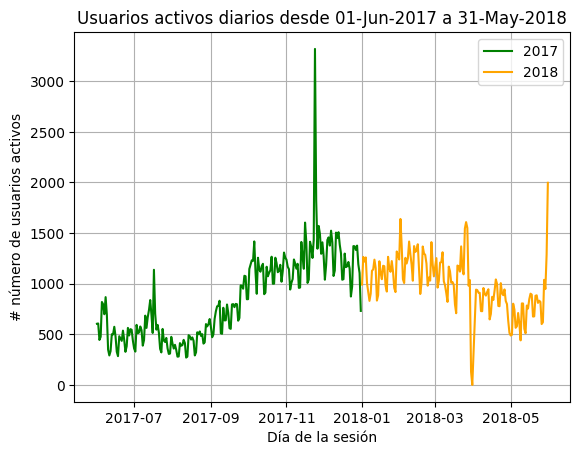

In [112]:
# DAU (Usuarios activos diarios únicos)

df_visits['session_year'] = df_visits['session_start'].dt.isocalendar().year    # Creamos columna para el año del dato de inicio de sesión
df_visits['session_month'] = df_visits['session_start'].dt.month                # Creamos columna para el mes del dato de inicio de sesión
df_visits['session_week'] = df_visits['session_start'].dt.isocalendar().week    # Creamos columna para la semana del año del dato de inicio de sesión
df_visits['session_date'] = df_visits['session_start'].dt.date                  # Creamos columna para la fecha del dato de inicio de sesión

# Para obtener DAU agrupamos por día y contamos los usuarios únicos que iniciaron sesión ese día 
dau = df_visits.groupby('session_date')['user_id'].nunique().reset_index()

# Obtenemos el valor máximo y mínimo (El día que más usuarios activos hubo y el día que menos hubo)
max_dau = dau['user_id'].max()
max_dau_date = dau.loc[dau['user_id'] == max_dau, 'session_date'].values[0]     # Localizamos el valor máximo
min_dau = dau['user_id'].min()
min_dau_date = dau.loc[dau['user_id'] == min_dau, 'session_date'].values[0]     # Localizamos el valor mínimo

# Transformamos la columna 'session_date' a formato to_datetime para separar los datos por fecha (2017 & 2018)
dau['session_date'] = pd.to_datetime(dau['session_date'])

# Filtramos DAU por año. Será útil para temas de visualización de los datos
dau_17 = dau[dau['session_date'].dt.year == 2017]
dau_18= dau[dau['session_date'].dt.year == 2018]

# Mostramos los resultados
print(f'El día con más usuarios activos fue', max_dau_date ,'con un total de:', max_dau)
print(f'El día con menos usuarios activos fue', min_dau_date,'con un total de:', min_dau)

# Creamos gráfico que muestre la variación de los usuarios activos por cada día desde 01-Jun-2017 hasta 31-May-2018

plt.plot(dau_17['session_date'],dau_17['user_id'],color='green',label='2017')   # Gráfico para los días del 2017
plt.plot(dau_18['session_date'],dau_18['user_id'],color='orange',label='2018')  # Gráfico para los días del 2018

plt.title('Usuarios activos diarios desde 01-Jun-2017 a 31-May-2018')
plt.xlabel('Día de la sesión')
plt.ylabel('# número de usuarios activos')
plt.legend()
plt.grid(True)

plt.show()

El DAU (Daily Active Users) mide los usuarios diarios únicos. No importa la duración de la sesión o si siguieron conectados en días posteriores, solamente si estuvieron activos ese día. Para calcularlo empleamos *session_start* que indica fecha y hora de inicio de sesión; agrupando por día, contamos el número de usuarios únicos. El día que más usuarios activos fue el 24 de Noviembre de 2017 con 3319, coinidiendo con el "Black Friday; por otra parte, el día que menos usuarios hubo fue el 31 de Marzo 2018 con 1 usuario activo. 

Para temas de visualización se filtraron los datos por año. Haciendo un breve análisis, se observa que hacía el fin del año 2017 la plataforma tiene un incremento en las visitas que se mantiene más o menos constante hasta los primeros meses del siguiente año. 

La semana con más usuarios activos fue la 47 con un total de: 10586
La semana con menos usuarios activos fue la 31 con un total de: 2364


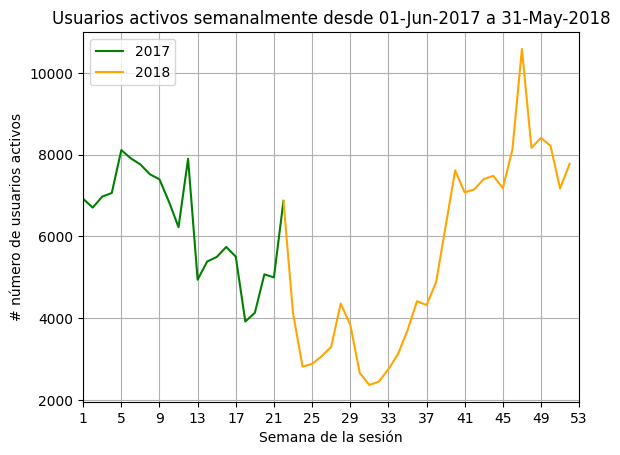

In [113]:
# WAU (Usuarios activos semanales únicos)

wau = df_visits.groupby('session_week')['user_id'].nunique().reset_index()

#print(wau)

# Obtenemos el valor máximo y mínimo (La semana que más usuarios activos hubo y la semana que menos hubo)
max_wau = wau['user_id'].max()
max_wau_date = wau.loc[wau['user_id'] == max_wau, 'session_week'].values[0]     # Localizamos el valor máximo
min_wau = wau['user_id'].min()
min_wau_date = wau.loc[wau['user_id'] == min_wau, 'session_week'].values[0]     # Localizamos el valor mínimo

# Al ser las semanas un 'float' se filtrará por semana del año. Los datos inciales (01-Jun-2017) son la semana "22" del año
# Filtramos WAU por año. Será útil para temas de visualización de los datos
wau_17 = wau[wau['session_week'] <= 22]
wau_18= wau[wau['session_week'] > 21]

# Mostramos los datos
print(f'La semana con más usuarios activos fue la', max_wau_date,'con un total de:', max_wau)
print(f'La semana con menos usuarios activos fue la', min_wau_date,'con un total de:', min_wau)

# Creamos gráfico que muestre la variación de los usuarios activos semanalmente desde 01-Jun-2017 hasta 31-May-2018

plt.plot(wau_17['session_week'],wau_17['user_id'],color='green',label='2017')   # Gráfico para las semanas del 2017
plt.plot(wau_18['session_week'],wau_18['user_id'],color='orange',label='2018')  # Gráfico para las semanas del 2018

plt.title('Usuarios activos semanalmente desde 01-Jun-2017 a 31-May-2018')
plt.xlabel('Semana de la sesión')
plt.ylabel('# número de usuarios activos')
plt.legend()
plt.grid(True)
plt.xlim(1,52)
plt.xticks(range(1,54,4))

plt.show()

El WAU (Weekly Active Users) mide los usuarios activos semanales. Al igual que el DAU, toma en consideración los usuarios activos semanalmente. Toma en consideración *session_start* y los toma por semana. 

Los datos empiezan a recopilarse el 1 de Junio de 2017, siendo la semana número 22 aproximadamente. Es imporante recalcar que las primeras 21 semanas del gráfico corresponden al periodo de 2018 y las semanas posteriores hasta la semana 52 son del año 2017. El gráfico muestra los usuarios activos por semana.

La semana que más usuarios activos hubo fue la 47, correspondiente del 20 de Noviembre 2017 al 26 de Noviembre 2017, coincidiendo nuevamente con el "Black Friday"; por otra parte, la semana que menos usuarios activos hubo fue la 31 cuyas fechas fueron del 31 de Julio al 6 de Agosto 2017.

El mes con más usuarios activos fue 11 con un total de: 32797
El mes con menos usuarios activos fue 8 con un total de: 11631


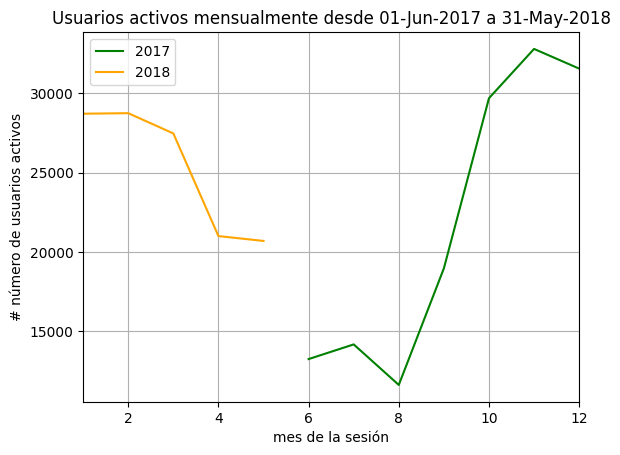

In [114]:
# MAU (Usuarios activos mensuales únicos)

mau = df_visits.groupby('session_month')['user_id'].nunique().reset_index()

#print(mau)

# Obtenemos el valor máximo y mínimo (El mes que más usuarios activos hubo y el mes que menos hubo)
max_mau = mau['user_id'].max()
max_mau_date = mau.loc[mau['user_id'] == max_mau, 'session_month'].values[0]        # Localizamos el valor máximo
min_mau = mau['user_id'].min()
min_mau_date = mau.loc[mau['user_id'] == min_mau, 'session_month'].values[0]        # Localizamos el valor mínimo

# Mostramos los datos
print(f'El mes con más usuarios activos fue', max_mau_date,'con un total de:', max_mau)
print(f'El mes con menos usuarios activos fue', min_mau_date,'con un total de:', min_mau)

# Filtramos MAU por año. Será útil para temas de visualización de los datos
mau_17 = mau[mau['session_month'] >= 6]
mau_18= mau[mau['session_month'] < 6]

# Creamos gráfico que muestre la variación de los usuarios activos mensualmente desde 01-Jun-2017 hasta 31-May-2018

plt.plot(mau_17['session_month'],mau_17['user_id'],color='green',label='2017')   # Gráfico para las semanas del 2017
plt.plot(mau_18['session_month'],mau_18['user_id'],color='orange',label='2018')  # Gráfico para las semanas del 2018

plt.title('Usuarios activos mensualmente desde 01-Jun-2017 a 31-May-2018')
plt.xlabel('mes de la sesión')
plt.ylabel('# número de usuarios activos')
plt.legend()
plt.grid(True)
plt.xlim(1,12)

plt.show()

El MAU (Monthly Active Users) mide los usuarios activos mensuales.  Al igual que el DAU y WAU,, toma en consideración los usuarios activos mensualmente, partiendo de *session_start* tomando el mes.

Los datos empiezan a recopilarse en Junio de 2017, siendo el mes 6. Es imporante recalcar que los primeros 6 meses del gráfico corresponden a Enero-Mayo de 2018, mientras que del mes 6 al 12 son Junio-Diciembre de 2017. El gráfico muestra los usuarios activos por mes.

El mes que más usuarios activos hubo fue el 11, siendo Noviembre de 2017, coincidiendo con la temporada de "Black Friday", mientras que el más flojo fue Agosto de 2017. 

#### 2. ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).

A difererencia del DAU, ahora incluimos los datos de aquellos usuarios que tuvieron más de 1 sesión al día. Cambiamos *nunique()* por *count()*

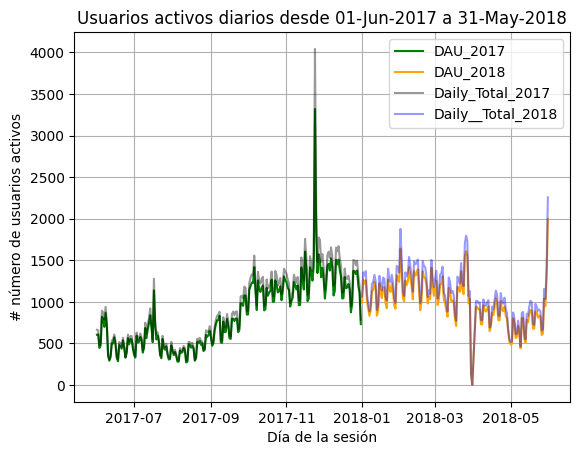

In [115]:
# Sesiones diarias

daily_sessions = df_visits.groupby('session_date')['user_id'].count().reset_index()


# Transformamos la columna 'session_date' a formato to_datetime para separar los datos por fecha (2017 & 2018)
daily_sessions['session_date'] = pd.to_datetime(daily_sessions['session_date'])

# Filtramos por año. Será útil para temas de visualización de los datos
daily_17 = daily_sessions[daily_sessions['session_date'].dt.year == 2017]
daily_18= daily_sessions[daily_sessions['session_date'].dt.year == 2018]

# Creamos gráfico que muestre la variación entre el DAU y las sesiones totales diarias desde 01-Jun-2017 hasta 31-May-2018

plt.plot(dau_17['session_date'],dau_17['user_id'], color='green',label='DAU_2017')                              # Gráfico para los días del 2017
plt.plot(dau_18['session_date'],dau_18['user_id'], color='orange',label='DAU_2018')                             # Gráfico para los días del 2018
plt.plot(daily_17['session_date'],daily_17['user_id'],color='black', label='Daily_Total_2017', alpha = 0.4)     # Gráfico para los días del 2017
plt.plot(daily_18['session_date'],daily_18['user_id'],color='blue', label='Daily__Total_2018', alpha = 0.4)     # Gráfico para los días del 2018


plt.title('Usuarios activos diarios desde 01-Jun-2017 a 31-May-2018')
plt.xlabel('Día de la sesión')
plt.ylabel('# número de usuarios activos')
plt.legend()
plt.grid(True)

plt.show()


In [116]:
# Promedio de usuarios diarios y sesiones únicas

# Aplicamos la función "ceil" para redondear al entero sigueinte
print(f'El promedio de sesiones diaras es:', math.ceil(daily_sessions['user_id'].mean()))   
print(f'El promedio de sesiones únicas diarias es:', math.ceil(dau['user_id'].mean()))

El promedio de sesiones diaras es: 988
El promedio de sesiones únicas diarias es: 908


El gráfico muestra la diferencia entre las sesiones únicas (DAU (verde & naranja)) y las sesiones totales (negro & morado), en el cual se aprecia una diferencia marcada en casi todo el año, siendo más las sesiones totales. El promedio de las sesiones diarias también es mayor a comparación de las sesiones únicas. 

A primera instancia, podemos asumir que varios usuarios ingresan en repetidas ocasiones.

#### 3. ¿Cuál es la duración de cada sesión?

La duración máxima de un usuario fue de: 0 days 11:51:00
La duración mínima de un usuario fue de: -1 days +23:14:00


Text(0, 0.5, 'Nanosegundos')

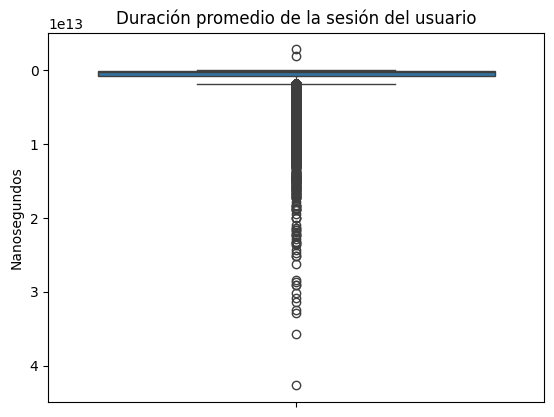

In [117]:
# Duración de cada sesión 

# Creamos "session_duration" que recopila las columnas 'session_end' y 'session_start'
session_duration = df_visits[['session_end','session_start']]

# 'session_time' marca la diferencia entre el fin e inicio de la sesión
session_time = session_duration['session_end'] - session_duration['session_start']

print(f'La duración máxima de un usuario fue de:',session_time.max())
print(f'La duración mínima de un usuario fue de:',session_time.min())

# Creamos un gráfico de 
sns.boxplot(session_time)
plt.title('Duración promedio de la sesión del usuario')
plt.ylabel('Nanosegundos')


En la primera visualización, vemos que hay un par de valores atípicos negativos, esto puede indicar un posible error durante la captura de los datos ya que no puede haber datos negativos (el inicio de sesión no pudo ocurrir después de que se finalizó la sesión). Para corregir esto, se filtran los datos para 'session_duration' tomando aquellos mayores o iguales que '0'.

Aprovechamos para pasar los datos a 'int' y mejorar la visualización de los mismos, además de simplificar su análisis pasándolos a minutos.

La duración máxima de un usuario fue de: 711.0 minutos
La duración mínima de un usuario fue de: 0.0 minutos
La duración promedio de un usuario fue de: 10.717371456342736 minutos
La mediana de los datos es: 5.0 minutos
La varianza de los datos es: 276.17112131901155


Text(0, 0.5, 'Minutos')

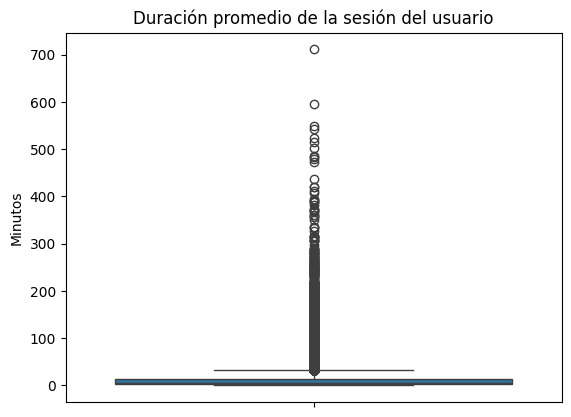

In [118]:
# Modificación de session_duration (filtramos por valores mayores o iguales a 0)
session_duration = df_visits[df_visits['session_end'] >= df_visits ['session_start']]

# Obtenemos una serie sin valores negativos para los tiempos
session_time = session_duration['session_end'] - session_duration['session_start']

# Pasamos los datos a tipo de dato 'int' y convertimos a minutos
session_time = (session_time.astype(int)/1000000000)/60

# Obtenemos la varianza
session_time_var = np.var(session_time)

# Para sacar la varianza necesitamos pasar el tipo de dato de 'timedelta' a minutos
print(f'La duración máxima de un usuario fue de:',session_time.max(), 'minutos')
print(f'La duración mínima de un usuario fue de:',session_time.min(), 'minutos')
print(f'La duración promedio de un usuario fue de:',session_time.mean(), 'minutos')
print(f'La mediana de los datos es:',session_time.median(), 'minutos')
print(f'La varianza de los datos es:',session_time_var)

# Creamos el gráfico sin los valores atípicos negativos
sns.boxplot(session_time)
plt.title('Duración promedio de la sesión del usuario')
plt.ylabel('Minutos')

Una alta varianza, de 276.17, nos indica que los datos están demasiado dispersos. Hay bastantes usuarios que se salen del promedio de 10.71 minutos por sesión. A falta de un análisis más profundo, el sitio podría encontrar estos datos relevantes si es que considera captar por más tiempo la atención de los usuarios, o por el contrario, tener menos tiempo de interacción.La mediana es de 5 minutos por sesión. 

El gráfico muestra una caja pequeña, con bigotes y mediana definidos, y bastantes valores atípicos.

#### 4. ¿Con qué frecuencia los usuarios regresan?

In [119]:
# Frecuencia de retorno

# Creamos dataframe que solamente contenga aquellos user_id duplicados, que significa que volvieron a iniciar sesión en otra ocasión. Ordenamos por fecha (menor a mayor)
v_user_dup = df_visits[df_visits.duplicated('user_id')]
v_user_dup = v_user_dup.sort_values(by = 'session_start', ascending = True)

# Creamos la columna 'date_diff' que indica aquellos usuarios que tienen un registro de fecha diferente asociado a un user_id
v_user_dup['date_diff'] = v_user_dup.groupby('user_id')['session_start'].diff()

# Retiramos los valores nulos que son aquellos del 'primer' registro de sesión
v_user_dup.dropna(subset=['date_diff'], inplace = True)

freq_user = v_user_dup['date_diff'].mean()

print(f'La frecuencia promedio de cuándo regresan los usuarios es:',freq_user)

La frecuencia promedio de cuándo regresan los usuarios es: 23 days 08:10:52.793446519


In [146]:
# Tasa de retención 

initial_user = df_visits['user_id'].count()                 # Usuarios iniciales
retention_user = v_user_dup['user_id'].count()              # Usuarios retenidos (que volvieron a iniciar sesión

retention_rate = (retention_user/initial_user)*100

print(f'La tasa de retención es: {retention_rate:.2f}%')

La tasa de retención es: 22.01%


De acuerdo con los datos recopilados, de los 359400 usuarios que iniciaron sesión 79103 volvieron a hacerlo en algún punto después de su primer actividad. 

### Ventas


#### 1. ¿Cuándo empieza la gente a comprar? (En el análisis de KPI, generalmente nos interesa saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario se convierte en cliente. Por ejemplo, si el registro y la primera compra ocurren el mismo día, el usuario podría caer en la categoría Conversion 0d. Si la primera compra ocurre al día siguiente, será Conversion 1d. Puedes usar cualquier enfoque que te permita comparar las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal de marketing es más efectivo.)

In [121]:
# Cuándo la gente empieza a comprar

# Concocer la primera vez que el usuario inició sesión
first_u_session = df_visits.groupby('user_id')['session_start'].min().reset_index()     # Agrupamos por usuario y obtenemos la primera vez que inició sesión
first_u_session = first_u_session.sort_values(by='session_start')                       # Ordenamos los datos de manera descendente

# Conocer la primera compra de un usuario 
first_u_purchase = df_orders.groupby('user_id')['purchase_time'].min().reset_index()    # Agrupamos por usuario y obtenemos la primera vez que hizo una compra 
first_u_purchase = first_u_purchase.sort_values(by='purchase_time')                     # Ordenamos los datos de manera ascendente

# Hacemos un merge para empatar la primera vez que el usuario inició sesión y su primera compra
merge_first_purchase = first_u_session.merge(first_u_purchase, on='user_id')

# Sacamos la diferencia entre la primera sesión y la primera compra por usuario
merge_first_purchase['time_diff'] = merge_first_purchase['purchase_time'] - merge_first_purchase['session_start']
merge_first_purchase['days'] = merge_first_purchase['time_diff'].dt.days                # Pasamor la diferencia de días a número de días para después categorizarlo

merge_first_purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36523 entries, 0 to 36522
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype          
---  ------         --------------  -----          
 0   user_id        36523 non-null  uint64         
 1   session_start  36523 non-null  datetime64[ns] 
 2   purchase_time  36523 non-null  datetime64[ns] 
 3   time_diff      36523 non-null  timedelta64[ns]
 4   days           36523 non-null  int64          
dtypes: datetime64[ns](2), int64(1), timedelta64[ns](1), uint64(1)
memory usage: 1.4 MB


In [122]:
# Definimos la función que nos ayudará a categorizar los datos

def category (days):            # La función recibe días y categoriza de acuerdo con los datos
    if days == 0:
        return '0d'
    elif days == 1:
        return '1d'
    elif days == 2:
        return '2d'
    elif 3 <= days <= 7:
        return '3d-7d'
    else:
        return '>7d' 

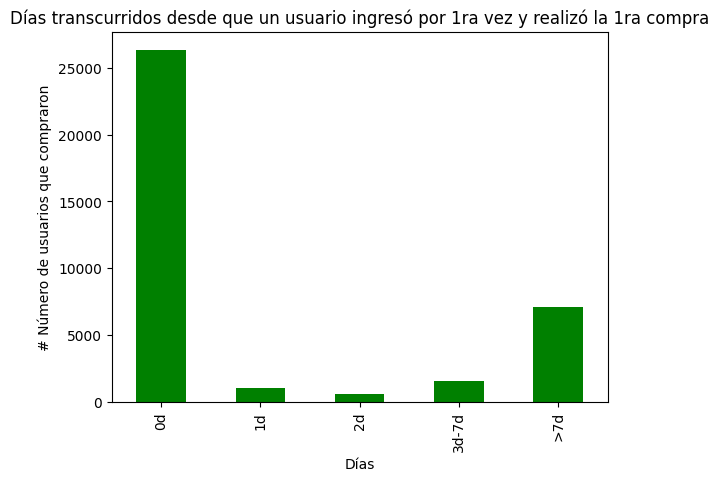

In [123]:
# Ejecutamos la categorización 

# Aplicamos la función y creamos la columna 'category'
merge_first_purchase['category'] = merge_first_purchase['days'].apply(category)

# Contamos los valores por categoría
count = merge_first_purchase['category'].value_counts().sort_index()

# Creamos un gráfico para visualizar
count.plot(
    title = 'Días transcurridos desde que un usuario ingresó por 1ra vez y realizó la 1ra compra',
    xlabel = 'Días',
    ylabel = '# Número de usuarios que compraron',
    kind = 'bar',
    color = 'green'
)

plt.show()

El gráfico muestra el tiempo transcurrido entre el primer inicio de sesión de los usuarios y la primer compra. Se hizo el análisis tomando la primera fecha de inicio de sesión, por primera vez, y la fecha de la compra, por vez primera. Analizando el gráfico, observamos que la gran mayoría de los usuarios que realizaron su primer compra iniciaron sesión el mismo día.

#### 2. ¿Cuántos pedidos hacen durante un período de tiempo dado?

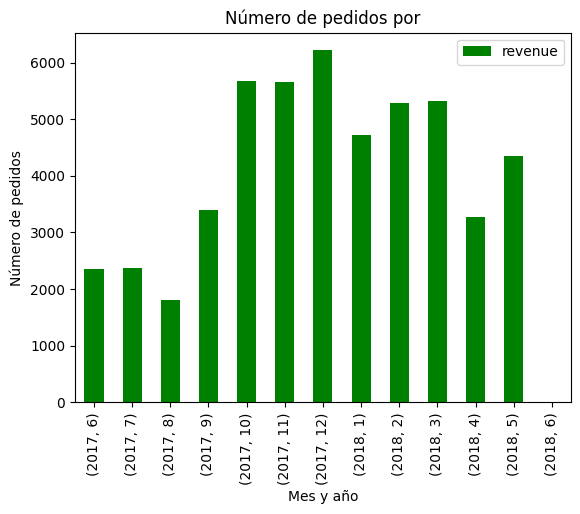

In [124]:
# Se opta por definir cuántos periodos se hacen por mes

# Añadimos columnas de mes y año al dataframe 'df_orders'
df_orders['purchase_month'] = df_orders['purchase_time'].dt.month
df_orders['purchase_year'] = df_orders['purchase_time'].dt.isocalendar().year

# Agrupamos por mes y año. Después, contamos cuántos pedidos hubo por cada mes
monthly_orders = df_orders.groupby(['purchase_year', 'purchase_month']).agg({
    'revenue' : 'count'
})

# Creamos un gráfico para visualizar los datos
monthly_orders.plot(
    title = 'Número de pedidos por',
    kind = 'bar',
    xlabel = 'Mes y año',
    ylabel = 'Número de pedidos',
    legend = '# pedidos',
    color = 'green'
)

plt.show()

Al separar los datos por mes, contamos cuántas compras se hicieron durante todo el mes. El gráfico nos muestra que el mes de mejores ventas fue Diciembre de 2017, mientras que el periodo de menor venta fue Agosto de 2017. 

Un dato curioso que se encontró fue que se realizó 1 sola compra la madrugada del 01-Junio-2018. Siendo el único valor registrado para ese mes, pues hasta ese momento contamos con nuestros datos para el análisis. 

#### 3. ¿Cuál es el tamaño promedio de compra?

In [125]:
# Tamaño promedio de compra total

tot_mean_revenue = df_orders['revenue'].mean()

print(f'El tamaño promedio de las compras durante el año es: {tot_mean_revenue:.2f}')

El tamaño promedio de las compras durante el año es: 5.00


El tamaño promedio de todas las compras durante todo el periodo de los datos es de 5$. Sin embargo, se opta por sacar el ARPU (Average return per user) para conocer el promedio de compras que un usuario "activo" deja en todo el periodo de tiempo.

In [126]:
# Cálculo de ARPU (Average return per user)

# Creamos el dataframe 'retention' que es un merge de df_orders y 'first_u_session' que sacamos anteriormente
# Podemos visualizar en un mismo dataframe la compra del usuario y el dato de su primer inicio de sesión
df_retention = df_orders.merge(first_u_session, on = 'user_id')

df_retention.rename(columns = {'session_start':'first_session'},inplace = True)                     # Renombramos la columna

df_retention['s_month'] = df_retention['first_session'].dt.month

# Obtenemos la diferencia de tiempo entre la compra y el primer inicio de sesión
df_retention['time_diff'] = (df_retention['purchase_time'] - df_retention['first_session'])

# Para pasarlo a meses, dividimos la diferencia entre pd.Timedelta(days=365/12) y lo pasamos como entero
df_retention['month_diff'] = ((df_retention['time_diff']) / pd.Timedelta(days=365/12)).astype(int)

df_retention.sample(5)


,purchase_time,revenue,user_id,purchase_month,purchase_year,first_session,s_month,time_diff,month_diff
45000,2018-04-21 21:42:00,0.00,4927261749585088199,4,2018,2018-04-21 13:02:00,4,0 days 08:40:00,0
25061,2017-12-20 17:18:00,1.83,2869867901439442769,12,2017,2017-12-13 15:04:00,12,7 days 02:14:00,0
16621,2017-11-08 12:53:00,3.05,6442897303992493932,11,2017,2017-11-08 12:53:00,11,0 days 00:00:00,0
44439,2018-04-17 21:07:00,2.44,17921283030339851807,4,2018,2018-04-17 21:07:00,4,0 days 00:00:00,0
12232,2017-10-11 17:54:00,5.50,17920504667421085216,10,2017,2017-10-11 17:48:00,10,0 days 00:06:00,0


<Axes: title={'center': 'Tamaño promedio de compra del cliente'}, xlabel='month_diff', ylabel='s_month'>

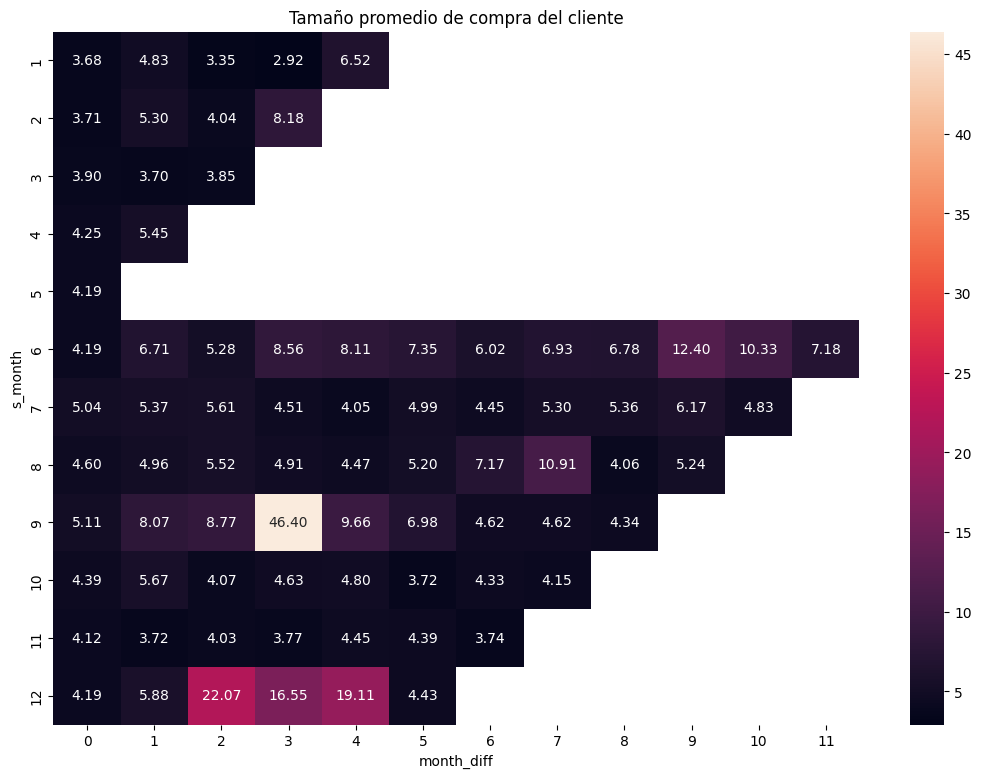

In [127]:
# Tamaño promedio de compra, agrupado por mes

cohort_pivot = df_retention.pivot_table(
    index = 's_month',
    columns = 'month_diff',
    values = 'revenue',
    aggfunc = 'mean'
)

plt.figure(figsize=(13, 9))
plt.title('Tamaño promedio de compra del cliente')

sns.heatmap(
    cohort_pivot,           # Datos
    annot = True,           # annot=True -> desplega valor por cada celda
    fmt='.2f',              # Formato de impresión, 2 decimales
)

El gráfico es un reflejo de la tabla pivote. El gráfico muestra aquellos usuarios que iniciaron sesión en determinado mes del año (1-12), y muestra las compras que hicieron a lo largo del año. Se puede decir que son usuarios "activos" porque siguieron comprando durante los siguientes meses.
* Por ejemplo: De todas las personas que iniciaron sesión por primera vez en Junio de 2017 tuvieron un promedio de compra de 4.19$ durante ese mes, para el siguiente mes (Julio) la cohorte de dichos usuarios registró un promedio de compra de 6.71$, y para el próximo (Agosto) de 5.28$ y así sucesivamente.

***NOTA:*** Cabe resaltar que puede que NO todos los usuarios hayan comprado en todos los meses. Un usuario que compró en Junio 2017 pudo registrar su siguiente adquisición varios meses después. Las cohortes(grupos) separan a las personas que iniciaron sesión en determinado mes y solamente muestran el promedio de compra en $ para los meses consecutivos.

El valor más alto registrado fue por los usuarios que iniciaron sesión por *primera vez* en Septiembre 2017 y adquirieron productos durante Diciembre 2017 con un valor de 46.4$. Es decir, las personas que iniciaron sesión en Septiembre 2017 gastaron la mayor cantidad.

Por otra parte, el valor más bajo fue por los usuarios que iniciaron sesión por *primera vez* en Enero 2018 y compraron durante el mes de Abril 2018 con un promedio de compra de 2.92$.

In [128]:
#purchase_by_user = df_retention.groupby(['user_id','purchase_month']).size().reset_index(name = 'purchase_num')

#print(purchase_by_user['purchase_num'].max())

In [129]:
df_retention

,purchase_time,revenue,user_id,purchase_month,purchase_year,first_session,s_month,time_diff,month_diff
0,2017-06-01 00:10:00,17.00,10329302124590727494,6,2017,2017-06-01 00:09:00,6,0 days 00:01:00,0
1,2017-06-01 00:25:00,0.55,11627257723692907447,6,2017,2017-06-01 00:14:00,6,0 days 00:11:00,0
2,2017-06-01 00:27:00,0.37,17903680561304213844,6,2017,2017-06-01 00:25:00,6,0 days 00:02:00,0
3,2017-06-01 00:29:00,0.55,16109239769442553005,6,2017,2017-06-01 00:14:00,6,0 days 00:15:00,0
4,2017-06-01 07:58:00,0.37,14200605875248379450,6,2017,2017-06-01 07:31:00,6,0 days 00:27:00,0
...,...,...,...,...,...,...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624,5,2018,2018-05-31 09:11:00,5,0 days 14:39:00,0
50411,2018-05-31 23:50:00,5.80,11369640365507475976,5,2018,2018-05-31 23:05:00,5,0 days 00:45:00,0
50412,2018-05-31 23:54:00,0.30,1786462140797698849,5,2018,2018-05-31 23:52:00,5,0 days 00:02:00,0
50413,2018-05-31 23:56:00,3.67,3993697860786194247,5,2018,2017-10-23 12:32:00,10,220 days 11:24:00,7


In [130]:
first_u_purchase['user_id'].nunique()

36523

In [131]:
first_u_purchase

,user_id,purchase_time
20437,10329302124590727494,2017-06-01 00:10:00
23018,11627257723692907447,2017-06-01 00:25:00
35477,17903680561304213844,2017-06-01 00:27:00
31908,16109239769442553005,2017-06-01 00:29:00
28100,14200605875248379450,2017-06-01 07:58:00
...,...,...
24312,12296626599487328624,2018-05-31 23:50:00
22509,11369640365507475976,2018-05-31 23:50:00
3534,1786462140797698849,2018-05-31 23:54:00
7919,3993697860786194247,2018-05-31 23:56:00


#### 4. ¿Cuánto dinero traen? (LTV)

In [ ]:
# Encontrar la fecha de primera compra de cada cliente, lo agrupamos por mes

# Empleamos 'first_u_purchase' que habíamos obtenido anteriormente
first_u_purchase['f_order_month'] = first_u_purchase['purchase_time'].dt.month          # Creamos columna que tiene el mes del primer inicio de sesión

# Renombramos la columna 'first_purchase'
first_u_purchase.rename(columns = {'purchase_time' : 'first_purchase'}, inplace = True)

first_u_purchase.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36523 entries, 20437 to 168
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         36523 non-null  uint64        
 1   first_purchase  36523 non-null  datetime64[ns]
 2   f_order_month   36523 non-null  int32         
dtypes: datetime64[ns](1), int32(1), uint64(1)
memory usage: 998.7 KB


In [133]:
# Calcular el número de nuevos clientes para cada mes

# Agrupamos por mes de compra y obtenemos los valores únicos del 'user_id'
new_users_p_month = df_retention.groupby('purchase_month').agg({'user_id': 'nunique'}).reset_index()

new_users_p_month.columns = ['f_order_month', 'n_buyers']               # Renombramos las columnas
new_users_p_month

,f_order_month,n_buyers
0,1,3898
1,2,4258
2,3,4181
3,4,2744
4,5,3544
5,6,2024
6,7,1984
7,8,1472
8,9,2750
9,10,4675


In [134]:
# Juntar ambos dataframes

df_cohort = pd.merge(df_retention, first_u_purchase, on = 'user_id')

df_cohort.head()

,purchase_time,revenue,user_id,purchase_month,purchase_year,first_session,s_month,time_diff,month_diff,first_purchase,f_order_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,6,2017,2017-06-01 00:09:00,6,0 days 00:01:00,0,2017-06-01 00:10:00,6
1,2017-06-01 00:25:00,0.55,11627257723692907447,6,2017,2017-06-01 00:14:00,6,0 days 00:11:00,0,2017-06-01 00:25:00,6
2,2017-06-01 00:27:00,0.37,17903680561304213844,6,2017,2017-06-01 00:25:00,6,0 days 00:02:00,0,2017-06-01 00:27:00,6
3,2017-06-01 00:29:00,0.55,16109239769442553005,6,2017,2017-06-01 00:14:00,6,0 days 00:15:00,0,2017-06-01 00:29:00,6
4,2017-06-01 07:58:00,0.37,14200605875248379450,6,2017,2017-06-01 07:31:00,6,0 days 00:27:00,0,2017-06-01 07:58:00,6


In [147]:
# Hacemos el cálculo para obtener el LTV (Lifetime value)

# Agrupamos por mes de primera orden y mes de compra, sumamos el valor de las ventas
cohorts_test = df_cohort.groupby(['f_order_month','purchase_month']).agg({'revenue': 'sum'}).reset_index()

report_cohorts = cohorts_test.merge(new_users_p_month, on = 'f_order_month')                # Unimos el dataframe con el de 'new_users_p_month'
report_m_revenue = report_cohorts.groupby('f_order_month')['revenue'].sum()                 # Agrupamos por primer orden y sumamos las ventas
m_cohort_revenue = pd.merge(report_m_revenue, new_users_p_month, on = 'f_order_month')      # Unimos ambos dataframes

# Recordando que LTV = Ingresos totales / No. de clientes
m_cohort_revenue['ltv'] = m_cohort_revenue['revenue'] / m_cohort_revenue['n_buyers']        # Creamos la columna LTV que muestra el valor mensual 

ltv = (m_cohort_revenue['revenue'].sum() - m_cohort_revenue['n_buyers'].sum())

print(f' El valor total de ciclo de vida de un cliente es:', ltv)
m_cohort_revenue

 El valor total de ciclo de vida de un cliente es: 211038.2


,f_order_month,revenue,n_buyers,ltv
0,1,16663.13,3898,4.274790
1,2,16750.50,4258,3.933889
2,3,19273.41,4181,4.609761
3,4,11810.61,2744,4.304158
4,5,13925.76,3544,3.929391
5,6,24035.11,2024,11.875054
6,7,16127.92,1984,8.128992
7,8,11606.26,1472,7.884688
8,9,34676.32,2750,12.609571
9,10,27603.45,4675,5.904481


El LTV muestra cuánto ingreso promedio genera un cliente adquirido en dicho periodo (mes). La tabla muestra que el valor más alto se lo llevan los usuarios que hicieron su primer compra en el mes 9 (Septiembre) donde hubo menos compradores, pero con mayores gastos; mientras que el valor más bajo fue en el mes 5 (Mayo), donde los compradores hicieron compras por menores precios.

El mes donde más usuarios realizaron su primera compra fue en Diciembre (12), mientras que el menor tráfico de compradores se dio en el mes de Agosto (8). 

### Marketing:

Traza gráficos para mostrar cómo difieren estas métricas para varios dispositivos y fuentes de anuncios y cómo cambian con el tiempo. 

#### 1. ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo) 

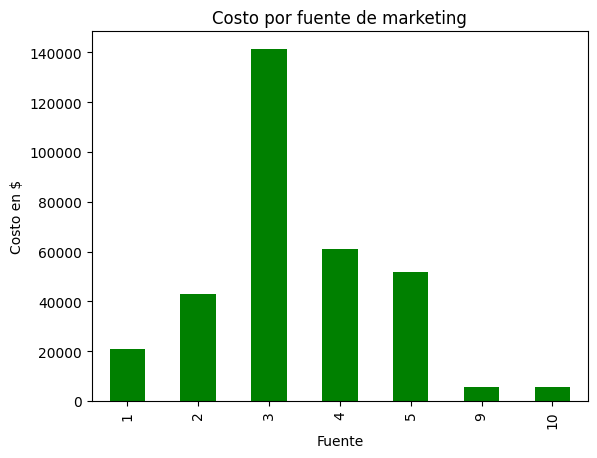

In [136]:
# Gastos por fuente de adquisición

# Agrupamos por fuente (source_id)
source_costs = df_costs.groupby('source_id')['source_cost'].sum()

# Creamos el gráfico para visualizar los datos
source_costs.plot(
    title = 'Costo por fuente de marketing',
    xlabel = 'Fuente',
    ylabel = 'Costo en $',
    kind = 'bar',
    color = 'green'
)

plt.show()

In [148]:
source_costs

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: source_cost, dtype: float64

El gráfico agrupa todas los canales y despliega cuánto se gasto por cada uno durante Jun-2017 hasta Mayo-2018. El canal número 3 fue el de mayor costo con 141,321 gastado en todo el año. Por otra parte, el canal que tuvo menor inversión fue el 9 con 5,517.

Otro dato relevante es que la segunda plataforma de mayor inversión (4), tuvo un gasto de  61,073. La fuente de mayor inversión supera (y por mucho) a todas las demás, demostrando que la empresa tiene potencial interés en atraer compradores a través de dicho canal.  

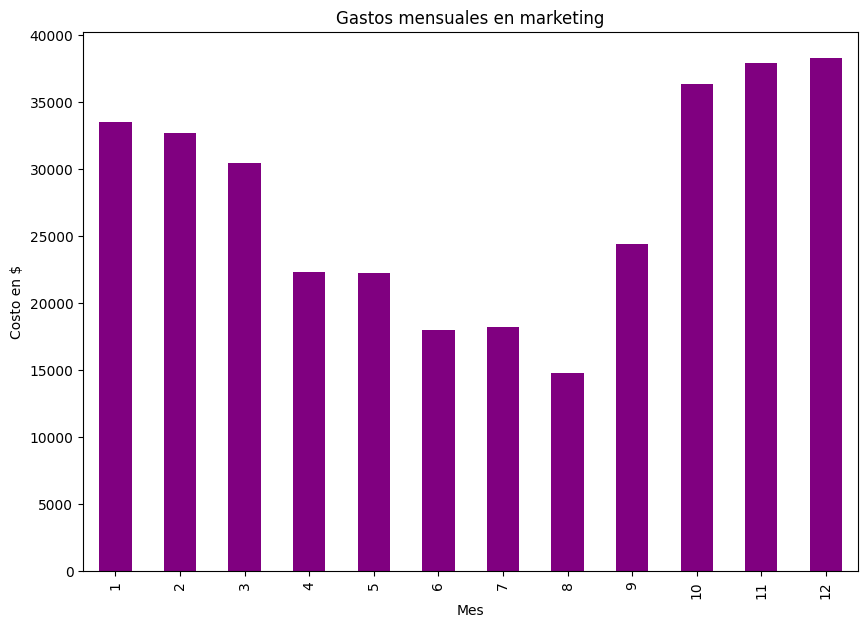

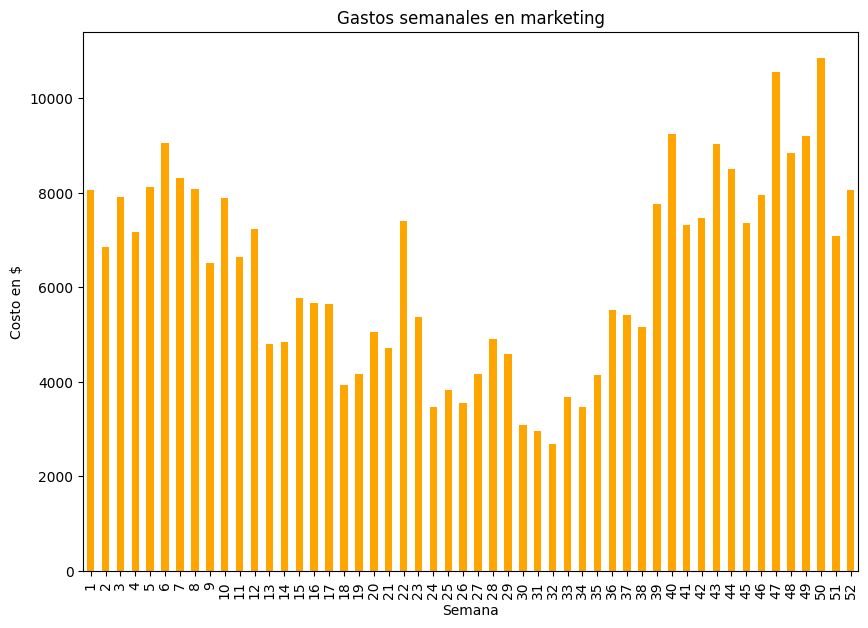

In [137]:
# Gastos por mes y semana

# Añadimos la columna de mes y semana al dataframe df_costs
df_costs['week'] = df_costs['date'].dt.isocalendar().week                       # Creamos columna de la semana
df_costs['month'] = df_costs['date'].dt.month                                   # Creamos columna del mes

monthly_costs = df_costs.groupby('month')['source_cost'].sum()                  # Agrupamos por mes y obtenemos los gastos mensuales
weekly_costs = df_costs.groupby('week')['source_cost'].sum()                    # Agrupamos por semana y obtenemos los gastos semanales

# Creamos los gráficos para visualizar los datos
monthly_costs.plot(
    title = 'Gastos mensuales en marketing',
    xlabel = 'Mes',
    ylabel = 'Costo en $',
    kind = 'bar',
    color = 'purple',
    figsize = [10,7]
)
plt.show()

weekly_costs.plot(
    title = 'Gastos semanales en marketing',
    xlabel = 'Semana',
    ylabel = 'Costo en $',
    kind = 'bar',
    color = 'orange',
    figsize = [10,7]
)

plt.show()


Se obtienen 2 gráficos, uno para el gasto mensual en recursos de marketing y otro para el costo semanal. Para el gráfico mensual, se puede apreciar que el equipo invierte una mayor cantidad en los meses de Noviembre y Diciembre, siendo más marcado en las semanas 47 (Noviembre) y 51 (Diciembre). Por otra parte, el periodo con un gasto en publicidad menor es Agosto, durante la semana 32. 

Se asume que esta estrategia tiene buenos resultados ya que las mayores visitas y ventas se dan durante los meses de Noviembre-Diciembre. 

In [138]:
# Gastos totales

print(f'El gasto total en marketing de Jun-2017 a Jun-2018 fue de:', df_costs['source_cost'].sum(),'$')

El gasto total en marketing de Jun-2017 a Jun-2018 fue de: 329131.62 $


#### 2. ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

In [139]:
# Obtenemos el CAC para cada fuente 

# Antes agregamos la columna 'session_date' a df_orders para poder hacer un merge con df_visits y que sea más preciso
df_orders['session_date'] = df_orders['purchase_time'].dt.date

# Creamos df_merged para saber de qué fuente vino cada cliente que compró. Después, calculamos el CAC por fuente.
df_merged = pd.merge(df_orders, df_visits, on = ['user_id','session_date'], how = 'inner')

df_merged


,purchase_time,revenue,user_id,purchase_month,purchase_year,session_date,device,session_end,source_id,session_start,session_year,session_month,session_week
0,2017-06-01 00:10:00,17.00,10329302124590727494,6,2017,2017-06-01,desktop,2017-06-01 00:11:00,1,2017-06-01 00:09:00,2017,6,22
1,2017-06-01 00:25:00,0.55,11627257723692907447,6,2017,2017-06-01,desktop,2017-06-01 00:25:00,2,2017-06-01 00:14:00,2017,6,22
2,2017-06-01 00:27:00,0.37,17903680561304213844,6,2017,2017-06-01,desktop,2017-06-01 00:34:00,2,2017-06-01 00:25:00,2017,6,22
3,2017-06-01 00:29:00,0.55,16109239769442553005,6,2017,2017-06-01,desktop,2017-06-01 00:33:00,2,2017-06-01 00:14:00,2017,6,22
4,2017-06-01 07:58:00,0.37,14200605875248379450,6,2017,2017-06-01,desktop,2017-06-01 07:59:00,3,2017-06-01 07:31:00,2017,6,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...
55023,2018-05-31 23:43:00,3.67,1805512004303848280,5,2018,2018-05-31,desktop,2018-05-31 23:02:00,2,2018-05-31 22:35:00,2018,5,22
55024,2018-05-31 23:50:00,4.64,12296626599487328624,5,2018,2018-05-31,desktop,2018-06-01 00:13:00,4,2018-05-31 23:46:00,2018,5,22
55025,2018-05-31 23:50:00,4.64,12296626599487328624,5,2018,2018-05-31,touch,2018-05-31 09:12:00,4,2018-05-31 09:11:00,2018,5,22
55026,2018-05-31 23:50:00,5.80,11369640365507475976,5,2018,2018-05-31,desktop,2018-05-31 23:55:00,10,2018-05-31 23:05:00,2018,5,22


Obtenemos un dataframe que muestra todas aquellos usuarios que registraron una visita y compraron un artículo. Conoceremos así los nuevos usuarios y el recurso de marketing por el que llegaron a la página. 

In [140]:
# Agrupamos por fuente de marketing y contamos los valores únicos de user_id
clients_source = df_merged.groupby('source_id')['user_id'].nunique().reset_index()

# Unimos ambos dataframes, de los usuarios nuevos y costos por cada recurso de marketing 
clients_merged = clients_source.merge(source_costs, on = 'source_id')

# Recordemos que el CAC = Costos / No. de nuevos usuarios
clients_merged['cac'] = clients_merged['source_cost'] / clients_merged['user_id']

clients_merged


,source_id,user_id,source_cost,cac
0,1,5219,20833.27,3.991813
1,2,4591,42806.04,9.323903
2,3,8995,141321.63,15.711132
3,4,9702,61073.60,6.294949
4,5,7391,51757.10,7.002720
5,9,948,5517.49,5.820137
6,10,1264,5822.49,4.606400


Los datos de la tabla nos indican que la fuente más costosa fue la "3"; sin embargo, no es la que atrajo a más nuevos usuarios. La fuente que introdujo a nuevos usuarios fue la "4", mientras que la de menor impacto fue la fuente "9".

#### 3. ¿Cuán rentables eran las inversiones? (ROMI)

In [141]:
# Obtenemos el ROMI (Retrun of marketing investment)

# Primero necesitamos calcular el LTV para el cohorte de 'source_id'
source_revenue = df_merged.groupby('source_id')['revenue'].sum().reset_index()     # Agrupamos por 'source_id' y sumamos las ventas de acuerdo a las personas que compraron siguiendo dicha fuente

source_revenue

,source_id,revenue
0,1,63165.14
1,2,69169.15
2,3,42124.75
3,4,48314.91
4,5,57089.68
5,7,1.22
6,9,3802.81
7,10,4367.69


In [142]:
# Conocemos cuántos usuarios nuevos compraron gracias a las fuentes de marketing 

# Agrupamos por 'source_id' y conocemos los usuarios únicos que compraron gracias a la fuente
new_users_p_source = df_merged.groupby('source_id').agg({'user_id':'nunique'}).reset_index()

new_users_p_source.columns = ['source_id', 'n_buyers']                          # Cambiamos el nombre de las columnas

new_users_p_source

,source_id,n_buyers
0,1,5219
1,2,4591
2,3,8995
3,4,9702
4,5,7391
5,7,1
6,9,948
7,10,1264


In [143]:
# Hacemos el cálculo del LTV y ROMI

# Unimos el dataframe de las ganancias con los nuevos usuarios. 
source_revenue_merged = source_revenue.merge(new_users_p_source, on = 'source_id')
source_revenue_merged['ltv'] = source_revenue_merged['revenue'] / source_revenue_merged['n_buyers']     # Creamos la columna LTV 

# Unimos el dataframe de los gastos de marketing con las ganancias
source_report = source_revenue_merged.merge(clients_merged, on = 'source_id')

# Recordemos que ROMI = LTV / CAC
source_report['romi'] = source_report['ltv'] / source_report['cac']                                     # Creamos la columna ROMI

source_report

,source_id,revenue,n_buyers,ltv,user_id,source_cost,cac,romi
0,1,63165.14,5219,12.102920,5219,20833.27,3.991813,3.031936
1,2,69169.15,4591,15.066249,4591,42806.04,9.323903,1.615874
2,3,42124.75,8995,4.683130,8995,141321.63,15.711132,0.298077
3,4,48314.91,9702,4.979892,9702,61073.60,6.294949,0.791093
4,5,57089.68,7391,7.724216,7391,51757.10,7.002720,1.103031
5,9,3802.81,948,4.011403,948,5517.49,5.820137,0.689228
6,10,4367.69,1264,3.455451,1264,5822.49,4.606400,0.750141


El ROMI lo obtuvimos al dividir el LTV entre el CAC para las fuentes de marketing. Se hizo el hallazgo de la fuente de marketing "7" que dejó un muy pequeño margen de ganancia (LTV) pero no se tienen registros de que se haya invertido en dicho recurso.

Por otra parte, la teoría aconseja que LTV debe ser mayor que el CAC y en la gran mayoría de los escenarios, salvo para las fuentes **1, 2 y 5** esta condición no se cumple. Se están invirtiendo demasiados recursos en canales que no atraen a la gran cantidad de personas. 

El canal con un mejor resultado es el "1", mientras que el más flojo es el "3".

## Paso 3. Escribe una conclusión: aconseja a los expertos de marketing cuánto dinero invertir y dónde

#### ¿Qué fuentes/plataformas recomendarías?  Fundamenta tu selección: ¿en qué métricas te enfocaste?  ¿Por qué? ¿Qué conclusiones sacaste después de encontrar los valores métricos?

Tras el análisis realizado, se recomienda seguir con la inversión en las plataformas **1, 2 y 5** que presentan los mejores resultados. 

Si bien, las plataformas **3 y 4** son las que más usuarios "convertidos" presentan, se están destinando demasiados recursos para atraerlos, razón por la que no se vuelve tan atractivo. Con un retorno de inversión de 0.29 y 0.79 respectivamente, significa que por cada peso/dólar invertido, se obtienen 29 y 79 centavos respectivamente. 

Las plataformas con mejor retorno de inversión son la **1,2 y 5**, devolviendo más de 1 peso/dólar en todos los casos. La sugerencia es destinar más recursos a estos canales. Está demostrado que con pocos recursos se puede atraer a una gran cantidad de compradores. Una sugerencia es destinar parte de los recursos actualmente enfocados en los canales **3 y 4** para dirigirlos hacia las plataformas **1, 2 y 5**

Finalmente, para las demás plataformas **7, 9 y 10**, su existencia representa un gasto mínimo en cuanto a marketing; no obstante, su retorno de inversión parece no ser "tan malo". Se sugiere a la compañía evaluar si es realmente necesario de contar con estas fuentes y de ser así, se aconseja un plan de mejora para estas fuentes.  

Otra conclusión hecha con base en en análisis es que la mayor parte de los usuarios visitaron la página el día del **"Black Friday"** de 2017, mientras que el mayor flujo de capital se dio en el mes de *Diciembre 2017*. Dicho esto, se sugiere que las campañas sean difundidas durante la etapa de fin de año a través de los canales que muestran mejor atracción de clientes. 

Por otra parte, los meses donde las campañas de marketing parecen no tener mucha influencia en las visitas a la página y por ende compras, es la época de Verano, entre los meses de Junio-Agosto. Se aconseja que las campañas publicitarias tengan una menor inversión durante este periodo.